# Training Pipeline - ChatKasir

- Nama: Achmad Rif'an (AI-1 Model Architect)
- Minggu: 2 - Pengembangan Fitur Inti (27 April - 1 Mei)


## 1. Setup Google Colab dengan GPU

In [58]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# verifikasi versi
print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")

TensorFlow : 2.20.0
NumPy      : 2.0.2
Pandas     : 2.2.2


In [59]:
# verifikasi GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"\nGPU tersedia: {len(gpus) > 0}")

if gpus:
    # tampilkan detail GPU yang aktif agar terdokumentasi
    for gpu in gpus:
        print(f"Nama GPU    : {gpu.name}")

    # aktifkan memory growth - GPU tidak langsung mengambil semua VRAM
    # tapi mengalokasikan secara bertahap sesuai kebutuhan
    # ini mencegah crash "out of memory" di awal training
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Memory growth: aktif")
else:
    print("PERINGATAN: GPU tidak aktif! Cek Runtime -> Change runtime type")


GPU tersedia: True
Nama GPU    : /physical_device:GPU:0
Memory growth: aktif


## 2. Load Dataset

In [60]:
# load dataset food
url_food_utama = "https://drive.google.com/uc?id=1xpoFjqAT9K0uwzSpVADm_EfKqG7dxVUI"

df_food = pd.read_csv(url_food_utama)
df_food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18558 entries, 0 to 18557
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    18558 non-null  object
dtypes: object(1)
memory usage: 145.1+ KB


In [61]:
# load dataset slang
url_slang_utama = "https://drive.google.com/uc?id=1G14C1qcqOp06Xs1HFiorE3Us_LLtaBs7"

df_slang = pd.read_csv(url_slang_utama)
df_slang.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   slang   1231 non-null   object
 1   formal  1231 non-null   object
dtypes: object(2)
memory usage: 19.4+ KB


In [62]:
# load dataset sintetis
url_synthetic_10000 = "https://drive.google.com/uc?id=15luIrYGJEZpbH-Wf7foXHXo3LBt0MBqU"

df_synthetic = pd.read_csv(url_synthetic_10000)
df_synthetic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   input_text    10050 non-null  object
 1   product       10050 non-null  object
 2   quantity      10050 non-null  int64 
 3   price_satuan  10050 non-null  int64 
 4   pattern       10050 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 392.7+ KB


## 3. Pipeline Data Loading
Ada 6 tahap yang dilakukan:

1. Memuat dan memvalidasi dataset
2. Tokenisasi: mengubah teks percakapan menjadi array integer
3. Encoding label: setiap nama produk dipetakan ke integer
4. Normalisasi price dan persiapan array
5. Split dataset menjadi training set dan validation set
6. Membangun tf.data.Dataset untuk mengirimkan data ke model saat training


### 3.1 Validasi Dataset Sintetis

In [63]:
print(f"Shape dataset   : {df_synthetic.shape}")
print(f"Kolom yang ada  : {list(df_synthetic.columns)}")


Shape dataset   : (10050, 5)
Kolom yang ada  : ['input_text', 'product', 'quantity', 'price_satuan', 'pattern']


In [64]:
# validasi nama kolom sesuai kesepakatan
kolom_wajib = ["input_text", "product", "quantity", "price_satuan", "pattern"]

kolom_hilang = [k for k in kolom_wajib if k not in df_synthetic.columns]
if kolom_hilang:
    print(f"ERROR: Kolom berikut tidak ditemukan: {kolom_hilang}")
    print("Minta Faradi (DS-1) untuk menyesuaikan nama kolom!")
else:
    print("Semua kolom sesuai")

Semua kolom sesuai


In [65]:
# tampilkan sampel data untuk inspeksi visual
print(f"Sampel 3 baris pertama:")
print(df_synthetic[["input_text", "product", "quantity", "price_satuan"]].head(3).to_string())

Sampel 3 baris pertama:
                                                                                                                  input_text                        product  quantity  price_satuan
0  minta 7 nasi kari limasari nasi putih ya [SEP] oke kak nasi kari limasari nasi putih harganya 22 ribu totalnya rp 154.000  nasi kari limasari nasi putih         7         22000
1                         bu mau pesen 4 mie goreng djawa [SEP] noted kak mie goreng djawa rp 48.000 per porsi totalnya 192k               mie goreng djawa         4         48000
2                                                                         4 teh obenk dong [SEP] oke kak pesanannya masuk ya                      teh obenk         4            -1


In [66]:
# cek distribusi pattern, memastikan proporsi seimbang
print(f"Distribusi pattern:")

for pattern, count in df_synthetic['pattern'].value_counts().sort_index().items():
    pct = count / len(df_synthetic) * 100
    print(f"Pola {pattern}: {count} baris ({pct:.1f}%)")

Distribusi pattern:
Pola 1: 3922 baris (39.0%)
Pola 2: 3888 baris (38.7%)
Pola 3: 2240 baris (22.3%)


In [67]:
# cek baris dengan harga satuan -1
n_null = (df_synthetic['price_satuan'] == -1).sum()

print(f"Baris tanpa harga satuan (-1): {n_null} ({n_null/len(df_synthetic):.1%})")

Baris tanpa harga satuan (-1): 1750 (17.4%)


In [68]:
# cek apakah ada nilai yang null (NaN)
print(f"Nilai NaN per kolom:")
print(df_synthetic[kolom_wajib].isnull().sum().to_string())

Nilai NaN per kolom:
input_text      0
product         0
quantity        0
price_satuan    0
pattern         0


In [69]:
# Pra Split indeks dahulu sebelum adapt() dipanggil.
# agar vocabulary tokenizer dan kamus produk hanya dibangun
# dari training data, bukan dari seluruh dataset termasuk validation.
# untuk mencegah data leakage: informasi dari validation set tidak boleh
# "bocor" ke proses pembangunan vocabulary.

idx_all = np.arange(len(df_synthetic))

idx_train, idx_val = train_test_split(
    idx_all,
    test_size = 0.2,
    random_state = 42,
    stratify = df_synthetic["pattern"].values
)

print(f"Indeks training : {len(idx_train)} baris (80%)")
print(f"Indeks validasi : {len(idx_val)} baris (20%)")
print(f"Indeks split siap dan adapt() akan menggunakan idx_train saja")

Indeks training : 8040 baris (80%)
Indeks validasi : 2010 baris (20%)
Indeks split siap dan adapt() akan menggunakan idx_train saja


### 3.2 Tokenisasi Teks
Mengubah teks chat obrolan pesanan pembeli dan penjual menjadi array integer menggunakan TextVectorization

In [70]:
# hyperparameter
# diambil dari 01_model_architecture.ipynb Minggu 1
VOCAB_SIZE = 10000
MAX_SEQ_LEN = 30
EMBEDDING_DIM = 128
LSTM_UNITS = 64

# TextVectorization
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE, # maksimum kata unik dalam kamus
    output_sequence_length=MAX_SEQ_LEN, # panjang urutan maksmimum
    output_mode="int", # output berupa integer (bukan one-hot)
    standardize="lower_and_strip_punctuation", # lowercase dan hapus tanda baca
    name="text_vectorizer"
)

print("Membangun kamus kata dari training data saja...")
vectorizer.adapt(df_synthetic["input_text"].iloc[idx_train].values)

Membangun kamus kata dari training data saja...


In [71]:
# verifikasi vocabulary yang terbentuk
vocab = vectorizer.get_vocabulary()

print(f"Kamus terbentuk dengan {len(vocab)} kata unik")
print(f"10 kata pertama (termasuk token khusus): {vocab[:5]}")
print(f"10 kata paling umum: {vocab[2:12]}")

# catatan: vocab[0] = "" (padding), vocab[1] = "[UNK]" (unknown)
# kata-kata selanjutnya diurutkan dari yang paling sering muncul

Kamus terbentuk dengan 3892 kata unik
10 kata pertama (termasuk token khusus): ['', '[UNK]', np.str_('kak'), np.str_('sep'), np.str_('ya')]
10 kata paling umum: [np.str_('kak'), np.str_('sep'), np.str_('ya'), np.str_('totalnya'), np.str_('nasi'), np.str_('ayam'), np.str_('oke'), np.str_('rp'), np.str_('dong'), np.str_('siap')]


In [72]:
# uji coba tokenisasi pada 1 contoh teks
contoh_teks = df_synthetic["input_text"].iloc[1]
contoh_token = vectorizer([contoh_teks]).numpy()[0]

print(f"Contoh tokenisasi:")
print(f"Teks asli: '{contoh_teks}'")
print(f"Hasil token: {contoh_token}")

Contoh tokenisasi:
Teks asli: 'bu mau pesen 4 mie goreng djawa [SEP] noted kak mie goreng djawa rp 48.000 per porsi totalnya 192k'
Hasil token: [  69   13   27   39   24   17 1334    3   21    2   24   17 1334    9
  192   15   16    5 2338    0    0    0    0    0    0    0    0    0
    0    0]


### 3.3 Encoding Label Product
Kolom product berisi string seperti "nasi goreng", "ayam geprek" maka diubah ke integer karena SparseCategoricalCrossentropy memproses label integer, bukan string

In [73]:
# StringLookup
# layer tensorflow yang memetakan string menjadi integer
# membuat kamus produk, tiap nama produk unik mendapat nomor urut yang konsisten
label_encoder_product = tf.keras.layers.StringLookup(
    output_mode="int",
    mask_token=None,
    name="product_label_encoder"
)

# fit label_encoder_product dengan seluruh nama produk unik di dataset
label_encoder_product.adapt(df_synthetic["product"].iloc[idx_train].values)

In [74]:
# jumlah kelas produk harus konsisten dengan NUM_PRODUCTS
# di arsitektur model 01_model_architecture.ipynb (+1 UNK)
NUM_PRODUCTS = label_encoder_product.vocabulary_size()

print(f"Jumlah kelas produk (NUM_PRODUCTS): {NUM_PRODUCTS}")
print(f"Catatan: angka ini harus sama dengan yang digunakan di build_model()")

Jumlah kelas produk (NUM_PRODUCTS): 4540
Catatan: angka ini harus sama dengan yang digunakan di build_model()


In [75]:
# uji coba encoding
contoh_produk = df_synthetic["product"].iloc[1]
contoh_encoded = label_encoder_product([contoh_produk]).numpy()[0]

print(f"Contoh label encoding:")
print(f"Nama produk : '{contoh_produk}'")
print(f"Hasil encode: {contoh_encoded}")

Contoh label encoding:
Nama produk : 'mie goreng djawa'
Hasil encode: 541


In [76]:
# simpan vocabulary label encoder untuk digunakan saat inferensi
# dibutuhkan untuk mengubah integer kembali ke nama produk
# (de-encoding) saat model sudah terlatih
produk_vocab = label_encoder_product.get_vocabulary()

print(f"5 produk pertama dalam kamus: {produk_vocab[:5]}")

# produk_vocab[0] = "[UNK]" untuk produk yang tidak dikenal
# produk_vocab[1:] = nama-nama produk yang dikenal

5 produk pertama dalam kamus: ['[UNK]', np.str_('nasi goreng chasiu'), np.str_('ice kopi taro'), np.str_('es kopi tem'), np.str_('chicken spaghetty')]


### 3.4 Normalisasi Price dan Persiapan Array

In [77]:
# tokenisasi seluruh input_text sekaligus
X = vectorizer(df_synthetic["input_text"].values).numpy()

print(f"Shape X (input model): {X.shape}")

Shape X (input model): (10050, 30)


In [78]:
# label encoding untuk product
y_product = label_encoder_product(df_synthetic["product"].values).numpy()

print(f"Shape y_product: {y_product.shape}")

Shape y_product: (10050,)


In [79]:
# quantity langsung diambil sebagai integer
y_quantity = df_synthetic["quantity"].values.astype(np.float32)

print(f"Shape y_quantity: {y_quantity.shape}")
print(f"Range quantity: {y_quantity.min():.0f} - {y_quantity.max():.0f}")

Shape y_quantity: (10050,)
Range quantity: 1 - 10


In [80]:
# price: normalisasi dengan membagi 1000
# kecuali baris dengan sentinel -1 yang harus dibiarkan -1
y_price_raw = df_synthetic["price_satuan"].values.astype(np.float32)

y_price_satuan = np.where(
    y_price_raw == -1,       # kondisi: kalau nilainya sentinel -1
    -1.0,                    # jika benar: biarkan -1 (jangan dinormalisasi)
    y_price_raw / 1000.0     # jika salah: normalisasi dengan bagi 1000
)

print(f"Shape y_price_satuan      : {y_price_satuan.shape}")
print(f"Range price valid (:1000) : {y_price_satuan[y_price_satuan != -1].min():.1f} – {y_price_satuan[y_price_satuan != -1].max():.1f}")
print(f"Jumlah sentinel -1        : {(y_price_satuan == -1).sum()}")

Shape y_price_satuan      : (10050,)
Range price valid (:1000) : 3.0 – 75.0
Jumlah sentinel -1        : 1750


### 3.5 Split Train & Validation
Menggunakan idx_train dan idx_val yang sudah dibuat sebelumnya (bukan train_test_split ulang — indeks sudah ditentukan di Pra-Split)

In [81]:
X_train, X_val = X[idx_train], X[idx_val]
y_product_train, y_product_val = y_product[idx_train], y_product[idx_val]
y_quantity_train, y_quantity_val = y_quantity[idx_train], y_quantity[idx_val]
y_price_satuan_train, y_price_satuan_val = y_price_satuan[idx_train], y_price_satuan[idx_val]

print(f"Training set   : {len(X_train)} baris (80%)")
print(f"Validation set : {len(X_val)} baris (20%)")

print(f"\nVerifikasi shape setelah split:")
print(f"X_train              : {X_train.shape}")
print(f"y_product_train      : {y_product_train.shape}")
print(f"y_price_satuan_train : {y_price_satuan_train.shape}")

Training set   : 8040 baris (80%)
Validation set : 2010 baris (20%)

Verifikasi shape setelah split:
X_train              : (8040, 30)
y_product_train      : (8040,)
y_price_satuan_train : (8040,)


### 3.6 Membangun tf.data.Dataset

Membungkus array numpy menjadi tf.data.Dataset yang siap digunakan untuk training atau validasi.

Parameter shuffle=True digunakan untuk training set agar urutan data acak setiap epoch. Mencegah model belajar pola berdasarkan urutan.

Untuk validation set, shuffle=False karena tidak diperlukan.

In [82]:
# model memproses 32 kalimat sekaligus dalam 1 langkah, bukan satu per satu
BATCH_SIZE = 32

def buat_dataset(X, y_product, y_quantity, y_price_satuan, shuffle=False):

    # dataset input: dictionary karena model.fit() mengharapkan format ini
    # saat model memiliki multiple inputs (meskipun di sini hanya satu input)
    dataset = tf.data.Dataset.from_tensor_slices((
        {"input_tokens": X}, # input ke model
        {   # label (target) untuk setiap output head
            "product": y_product,
            "quantity": y_quantity,
            "price_satuan": y_price_satuan
        }
    ))

    if shuffle:
        # buffer size = jumlah data
        dataset = dataset.shuffle(buffer_size=len(X), seed=42)

    dataset = dataset.batch(BATCH_SIZE)

    # prefetch(tf.data.AUTOTUNE): saat GPU sedang melatih batch ke-N,
    # CPU sudah mempersiapkan batch ke-N+1 di background
    # ini menghilangkan "waktu menunggu" antara batch dan mempercepat training
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

train_dataset = buat_dataset(
    X_train, y_product_train, y_quantity_train, y_price_satuan_train, shuffle=True
)

val_dataset = buat_dataset(
    X_val, y_product_val, y_quantity_val, y_price_satuan_val, shuffle=False
)

# hitung jumlah batch
n_train_batches = len(X_train) // BATCH_SIZE
n_val_batches   = len(X_val) // BATCH_SIZE

print(f"Training dataset   : {n_train_batches} batch x {BATCH_SIZE} sampel")
print(f"Validation dataset : {n_val_batches} batch x {BATCH_SIZE} sampel")

Training dataset   : 251 batch x 32 sampel
Validation dataset : 62 batch x 32 sampel


In [83]:
# verifikasi satu batch untuk memastikan format sudah benar
print(f"Verifikasi format satu batch:")

for inputs_batch, labels_batch in train_dataset.take(1):
    print(f"Input 'input_tokens' shape : {inputs_batch['input_tokens'].shape}")
    print(f"Label 'product' shape      : {labels_batch['product'].shape}")
    print(f"Label 'quantity' shape     : {labels_batch['quantity'].shape}")
    print(f"Label 'price_satuan' shape : {labels_batch['price_satuan'].shape}")

Verifikasi format satu batch:
Input 'input_tokens' shape : (32, 30)
Label 'product' shape      : (32,)
Label 'quantity' shape     : (32,)
Label 'price_satuan' shape : (32,)


## 4. Tokenisasi, Padding & Encoding Label
Bagian ini memperdalam dan memverifikasi secara eksplisit setiap tahap encoding yang sudah dijalankan di Bagian 3.

Tujuannya adalah memastikan setiap komponen pipeline bekerja benar sebelum digunakan untuk training model, dan mendokumentasikan keputusan teknis untuk referensi AI-2 (Denny) dan laporan teknis DS-2 (Salman).

### 4.1 Verifikasi Mendalam Tokenisasi (input_text)

In [84]:
# Tahap 2 di bagian sebelumnya sudah menjalankan tokenisasi secara massal.
# di sini verifikasi cara kerjanya secara eksplisit pada satu contoh
# untuk memastikan tidak ada kesalahan yang tersembunyi.

# ambil vocabulary yang sudah terbentuk dari vectorizer
vocab = vectorizer.get_vocabulary()
print(f"Total kata dalam kamus  : {len(vocab)}")
print(f"\nStruktur kamus (4 slot pertama):")
print(f"  vocab[0] = '{vocab[0]}' token PADDING (integer 0 = 'kosong')")
print(f"  vocab[1] = '{vocab[1]}' token [UNK] untuk kata tidak dikenal")
print(f"  vocab[2] = '{vocab[2]}' kata PALING SERING muncul di dataset")
print(f"  vocab[3] = '{vocab[3]}' kata terbanyak kedua")
print(f"  vocab[4:9] = {vocab[4:9]}")

Total kata dalam kamus  : 3892

Struktur kamus (4 slot pertama):
  vocab[0] = '' token PADDING (integer 0 = 'kosong')
  vocab[1] = '[UNK]' token [UNK] untuk kata tidak dikenal
  vocab[2] = 'kak' kata PALING SERING muncul di dataset
  vocab[3] = 'sep' kata terbanyak kedua
  vocab[4:9] = [np.str_('ya'), np.str_('totalnya'), np.str_('nasi'), np.str_('ayam'), np.str_('oke')]


In [85]:
# ambil satu contoh nyata dari dataset
idx_contoh    = 0
teks_contoh   = df_synthetic["input_text"].iloc[idx_contoh]
produk_contoh = df_synthetic["product"].iloc[idx_contoh]
qty_contoh    = df_synthetic["quantity"].iloc[idx_contoh]
price_contoh  = df_synthetic["price_satuan"].iloc[idx_contoh]

print(f"Contoh baris ke-{idx_contoh}:")
print(f"input_text   : '{teks_contoh}'")
print(f"product      : '{produk_contoh}'")
print(f"quantity     : {qty_contoh}")
print(f"price_satuan : {price_contoh}")

Contoh baris ke-0:
input_text   : 'minta 7 nasi kari limasari nasi putih ya [SEP] oke kak nasi kari limasari nasi putih harganya 22 ribu totalnya rp 154.000'
product      : 'nasi kari limasari nasi putih'
quantity     : 7
price_satuan : 22000


In [86]:
# tokenisasi satu kalimat untuk verifikasi
token_result = vectorizer([teks_contoh]).numpy()[0]

print(f"Hasil tokenisasi (array {MAX_SEQ_LEN} integer):")
print(f"{token_result}")

Hasil tokenisasi (array 30 integer):
[  33   32    6  317  357    6  134    4    3    8    2    6  317  357
    6  134   28  638   14    5    9 3872    0    0    0    0    0    0
    0    0]


In [87]:
# analisis token bermakna & padding
n_bermakna = int(np.sum(token_result != 0))
n_padding  = int(np.sum(token_result == 0))

print(f"Analisis:")
print(f"Token bermakna (bukan 0) : {n_bermakna}")
print(f"Token padding  (angka 0) : {n_padding}")
print(f"Kalimat ini menggunakan {n_bermakna}/{MAX_SEQ_LEN} slot")

Analisis:
Token bermakna (bukan 0) : 22
Token padding  (angka 0) : 8
Kalimat ini menggunakan 22/30 slot


In [88]:
# de-tokenisasi untuk verifikasi mengubah integer menjadi kata
print(f"De-tokenisasi (mengubah integer menjadi kata):")

for i, token_id in enumerate(token_result[:n_bermakna]):
    kata = vocab[token_id] if token_id < len(vocab) else "[UNK]"
    print(f"  token[{i:02d}] = {token_id:5d} -> '{kata}'")

De-tokenisasi (mengubah integer menjadi kata):
  token[00] =    33 -> 'minta'
  token[01] =    32 -> '7'
  token[02] =     6 -> 'nasi'
  token[03] =   317 -> 'kari'
  token[04] =   357 -> 'limasari'
  token[05] =     6 -> 'nasi'
  token[06] =   134 -> 'putih'
  token[07] =     4 -> 'ya'
  token[08] =     3 -> 'sep'
  token[09] =     8 -> 'oke'
  token[10] =     2 -> 'kak'
  token[11] =     6 -> 'nasi'
  token[12] =   317 -> 'kari'
  token[13] =   357 -> 'limasari'
  token[14] =     6 -> 'nasi'
  token[15] =   134 -> 'putih'
  token[16] =    28 -> 'harganya'
  token[17] =   638 -> '22'
  token[18] =    14 -> 'ribu'
  token[19] =     5 -> 'totalnya'
  token[20] =     9 -> 'rp'
  token[21] =  3872 -> '154000'


### 4.2 Demonstrasi Encoding 3 Entitas

Setiap entitas (product, quantity, price_satuan) memiliki pendekatan encoding yang berbeda karena sifat datanya berbeda.

In [89]:
# Entitas 1: PRODUCT

# verifikasi label_encoder_product yang sudah di-fit di Tahap 3
# vocabulary_size() = jumlah produk unik + 1 slot [UNK]
NUM_PRODUCTS = label_encoder_product.vocabulary_size()

print(f"Jumlah kelas products (termasuk [UNK]) : {NUM_PRODUCTS}")
print(f"Produk unik di dataset        : {NUM_PRODUCTS - 1}")
print(f"Slot [UNK] (produk baru)      : 1")
print(f"Total NUM_PRODUCTS            : {NUM_PRODUCTS}")

# catatan: NUM_PRODUCTS = 4976 (bukan 4975)
# perbedaan dari estimasi Minggu 1 karena StringLookup
# otomatis menambahkan 1 slot [UNK]

Jumlah kelas products (termasuk [UNK]) : 4540
Produk unik di dataset        : 4539
Slot [UNK] (produk baru)      : 1
Total NUM_PRODUCTS            : 4540


In [90]:
# demonstrasi encoding & deencoding beberapa nama produk
print(f"Demonstrasi encoding & deencoding nama produk:")

contoh_produk = df_synthetic["product"].unique()[:5]

# buat de-encoder untuk dipakai saat inferensi
# model mengembalikan integer ke string yang dapat dibaca manusia
label_decoder_product = tf.keras.layers.StringLookup(
    vocabulary=label_encoder_product.get_vocabulary(),
    invert=True,
    name="product_label_decoder"
)

for nama in contoh_produk:
    encoded = label_encoder_product([nama]).numpy()[0]
    decoded = label_decoder_product([encoded]).numpy()[0].decode("utf-8")
    status  = "OKE" if decoded == nama else "NO"

    print(f"'{nama}' -> {encoded:4d} -> '{decoded}' {status}")

Demonstrasi encoding & deencoding nama produk:
'nasi kari limasari nasi putih' ->  140 -> 'nasi kari limasari nasi putih' OKE
'mie goreng djawa' ->  541 -> 'mie goreng djawa' OKE
'teh obenk' -> 2394 -> 'teh obenk' OKE
'strawberry smoothies with ice cream' -> 2480 -> 'strawberry smoothies with ice cream' OKE
'ayam sambal ijo' ->  834 -> 'ayam sambal ijo' OKE


In [91]:
# Entitas 2: QUANTITY
# quantity sudah berupa integer di dataset, tidak perlu encoding khusus
# tapi perlu dikonversi ke float32 karena TensorFlow bekerja dengan float
# dan perlu diverifikasi range yang masuk akal

y_quantity = df_synthetic["quantity"].values.astype(np.float32)

print(f"Shape y_quantity : {y_quantity.shape}")
print(f"Tipe data        : {y_quantity.dtype}")
print(f"Range nilai      : {y_quantity.min():.0f} - {y_quantity.max():.0f} porsi")
print(f"Rata-rata        : {y_quantity.mean():.2f} porsi")

Shape y_quantity : (10050,)
Tipe data        : float32
Range nilai      : 1 - 10 porsi
Rata-rata        : 5.50 porsi


In [92]:
# distribusi nilai quantity
print(f"Distribusi nilai quantity di dataset sintetis:")

unique_qty, counts_qty = np.unique(y_quantity, return_counts=True)

for qty, count in zip(unique_qty, counts_qty):
    bar = " " * (count // 80)
    pct = count / len(y_quantity) * 100

    print(f"qty={qty:.0f}: {count:5d} baris ({pct:.1f}%) {bar}")

# catatan: tidak ada normalisasi untuk quantity
# range 1-10 sudah proporsional dengan output relu
# model akan memprediksi float, dibulatkan ke int saat inferensi

Distribusi nilai quantity di dataset sintetis:
qty=1:  1007 baris (10.0%)             
qty=2:   995 baris (9.9%)             
qty=3:  1016 baris (10.1%)             
qty=4:  1003 baris (10.0%)             
qty=5:  1013 baris (10.1%)             
qty=6:   995 baris (9.9%)             
qty=7:  1025 baris (10.2%)             
qty=8:   984 baris (9.8%)             
qty=9:   997 baris (9.9%)             
qty=10:  1015 baris (10.1%)             


In [93]:
# Entitas 3: PRICE_SATUAN
# ada 2 jenis nilai:
# 1) harga valid: 3000, 5000, 10000, ...
# 2) sentinel -1: menandai baris tanpa harga (harus dijaga -1, tidak dinormalisasi)
# normalisasi hanya diterapkan pada harga valid, sentinel -1 dibiarkan utuh
# karena MaskedPriceLoss akan mendeteksi -1 dan mengecualikannya dari loss

# pisahkan untuk analisis
mask_valid    = y_price_satuan != -1
mask_sentinel = y_price_satuan == -1

print(f"Shape y_price_satuan: {y_price_satuan.shape}")
print(f"Baris harga valid   : {mask_valid.sum()} ({mask_valid.mean():.1%})")
print(f"Baris sentinel -1   : {mask_sentinel.sum()} ({mask_sentinel.mean():.1%})")

print(f"\nStatistik harga valid sebelum normalisasi (rupiah):")
price_valid_raw = y_price_satuan[mask_valid] * 1000  # balik ke rupiah untuk display
print(f"Minimum  : Rp {price_valid_raw.min():,.0f}")
print(f"Maksimum : Rp {price_valid_raw.max():,.0f}")
print(f"Rata-rata: Rp {price_valid_raw.mean():,.0f}")

print(f"\nStatistik harga valid setelah normalisasi (:1000):")
print(f"Minimum  : {y_price_satuan[mask_valid].min():.1f}")
print(f"Maksimum : {y_price_satuan[mask_valid].max():.1f}")
print(f"Rata-rata: {y_price_satuan[mask_valid].mean():.1f}")

Shape y_price_satuan: (10050,)
Baris harga valid   : 8300 (82.6%)
Baris sentinel -1   : 1750 (17.4%)

Statistik harga valid sebelum normalisasi (rupiah):
Minimum  : Rp 3,000
Maksimum : Rp 75,000
Rata-rata: Rp 39,058

Statistik harga valid setelah normalisasi (:1000):
Minimum  : 3.0
Maksimum : 75.0
Rata-rata: 39.1


In [94]:
# verifikasi jumlah price_satuan -1 tidak berubah
assert (y_price_satuan == -1).sum() == mask_sentinel.sum(), \
    "ERROR: Jumlah price_satuan -1 berubah setelah normalisasi"

print(f"Jumlah price_satuan -1 tetap utuh setelah normalisasi")

Jumlah price_satuan -1 tetap utuh setelah normalisasi


In [95]:
# perbandingan skala setelah normalisasi
# tujuannya memastikan keduanya berada dalam range yang serupa
print(f"Perbandingan skala setelah normalisasi:")
print(f"quantity (tanpa normalisasi) : {y_quantity.min():.1f} - {y_quantity.max():.1f}")
print(f"price_satuan (:1000)         : {y_price_satuan[mask_valid].min():.1f} - {y_price_satuan[mask_valid].max():.1f}")

# catatan: skala lebih proporsional, loss tidak didominasi oleh price
# De-normalisasi untuk AI-2 (Denny)
# Output model (skala :1000) x 1000 = rupiah sesungguhnya
# Contoh: model output 10.5 x 1000 = Rp 10.500

Perbandingan skala setelah normalisasi:
quantity (tanpa normalisasi) : 1.0 - 10.0
price_satuan (:1000)         : 3.0 - 75.0


### 4.3 Verifikasi Konsistensi Semua Array

Memastikan semua array memiliki panjang yang sama dan setiap baris ke-N di X, y_product, y_quantity, y_price_satuan merujuk ke transaksi yang sama (tidak ada data yang "bergeser").

In [96]:
# cek panjang semua array
print("Panjang setiap array:")
print(f"X              : {len(X)}")
print(f"y_product      : {len(y_product)}")
print(f"y_quantity     : {len(y_quantity)}")
print(f"y_price_satuan : {len(y_price_satuan)}")

assert len(X) == len(y_product) == len(y_quantity) == len(y_price_satuan), \
    "ERROR: Panjang array tidak konsisten!"
print(f"\nSemua array konsisten - {len(X)} baris")

# ambil 3 indeks acak dan verifikasi bahwa seluruh pipeline bekerja benar
print(f"\nVerifikasi 3 sampel acak:")
np.random.seed(42)
idx_sampel = np.random.choice(len(df_synthetic), size=3, replace=False)

for i, idx in enumerate(idx_sampel):
    teks_asli   = df_synthetic["input_text"].iloc[idx]
    produk_asli = df_synthetic["product"].iloc[idx]
    qty_asli    = df_synthetic["quantity"].iloc[idx]
    price_asli  = df_synthetic["price_satuan"].iloc[idx]

    token_arr     = X[idx]
    product_int   = y_product[idx]
    qty_float     = y_quantity[idx]
    price_norm    = y_price_satuan[idx]

    # de-encode product
    produk_decoded = label_decoder_product(
        [product_int]
    ).numpy()[0].decode("utf-8")

    # de-normalisasi price (kalikan 1000, kecuali -1)
    price_denorm = price_norm * 1000 if price_norm != -1 else -1

    # verifikasi kecocokan produk encode decode
    cocok = "OKE" if produk_decoded == produk_asli else "NO"

    print(f"\nSampel {i+1} (baris ke-{idx}):")
    print(f"Teks     : '{teks_asli[:55]}...'")
    print(f"Product  : '{produk_asli}' -> {product_int} -> '{produk_decoded}' {cocok}")
    print(f"Quantity : {qty_asli} -> float: {qty_float:.1f}")

    if price_asli == -1:
      print(f"Price: {price_asli} (sentinel) -> normalized: {price_norm}")
    else:
      print(f"Price: Rp{price_asli:,} -> :1000: {price_norm:.1f} -> x1000: Rp{price_denorm:,.0f}")

    assert produk_decoded == produk_asli, f"De-encoding gagal untuk '{produk_asli}'"

print(f"\nSemua sampel terverifikasi - pipeline berjalan benar")

Panjang setiap array:
X              : 10050
y_product      : 10050
y_quantity     : 10050
y_price_satuan : 10050

Semua array konsisten - 10050 baris

Verifikasi 3 sampel acak:

Sampel 1 (baris ke-8776):
Teks     : 'kak mau order 1 es teh ya [SEP] oke kak es teh harganya...'
Product  : 'es teh' -> 672 -> 'es teh' OKE
Quantity : 1 -> float: 1.0
Price: Rp21,000 -> :1000: 21.0 -> x1000: Rp21,000

Sampel 2 (baris ke-2199):
Teks     : 'bu 1 nasi simangunsong [SEP] nasi simangunsong 7k ya ka...'
Product  : 'nasi simangunsong' -> 1175 -> 'nasi simangunsong' OKE
Quantity : 1 -> float: 1.0
Price: Rp7,000 -> :1000: 7.0 -> x1000: Rp7,000

Sampel 3 (baris ke-9596):
Teks     : 'mau 7 chicken wings ya kak [SEP] oke kak chicken wings ...'
Product  : 'chicken wings' -> 1969 -> 'chicken wings' OKE
Quantity : 7 -> float: 7.0
Price: Rp23,000 -> :1000: 23.0 -> x1000: Rp23,000

Semua sampel terverifikasi - pipeline berjalan benar


### 4.4 Simpan Komponen Pipeline ke Google Drive

Menyimpan vocabulary tokenizer dan label encoder ke Google Drive
agar bisa digunakan kembali saat inferensi tanpa fit ulang dari nol.
File-file ini dibutuhkan oleh AI-2 (Denny) untuk preprocessing
di sisi FastAPI.

In [97]:
import json, os

# buat folder pipeline di Drive
DRIVE_BASE  = "/content/drive/MyDrive/ChatKasir/"
PIPELINE_DIR = os.path.join(DRIVE_BASE, "pipeline/")
os.makedirs(PIPELINE_DIR, exist_ok=True)

# simpan vocabulary tokenizer sebagai JSON
vocab        = vectorizer.get_vocabulary()
vocab_dict   = {word: int(idx) for idx, word in enumerate(vocab)}
vocab_path   = os.path.join(PIPELINE_DIR, "tokenizer_vocab.json")

with open(vocab_path, "w", encoding="utf-8") as f:
    json.dump(vocab_dict, f, ensure_ascii=False, indent=2)

print(f"tokenizer_vocab.json disimpan ({len(vocab_dict)} kata)")

tokenizer_vocab.json disimpan (3892 kata)


In [98]:
# simpan vocabulary label encoder produk sebagai JSON
produk_vocab      = label_encoder_product.get_vocabulary()
produk_vocab_dict = {nama: int(idx) for idx, nama in enumerate(produk_vocab)}
produk_path       = os.path.join(PIPELINE_DIR, "product_vocab.json")

with open(produk_path, "w", encoding="utf-8") as f:
    json.dump(produk_vocab_dict, f, ensure_ascii=False, indent=2)

print(f"product_vocab.json disimpan ({len(produk_vocab_dict)} produk)")

product_vocab.json disimpan (4540 produk)


In [99]:
# simpan konfigurasi hyperparameter yang dipakai pipeline
# file ini sebagai "kontrak teknis" untuk AI-2 (Denny)
pipeline_config = {
    "VOCAB_SIZE": VOCAB_SIZE,
    "MAX_SEQ_LEN": MAX_SEQ_LEN,
    "NUM_PRODUCTS": int(NUM_PRODUCTS),
    "PRICE_NORM_FACTOR": 1000,
    "PRICE_SENTINEL": -1,
    "catatan_untuk_denny": {
        "tokenizer": "Gunakan tokenizer_vocab.json untuk mereplikasi TextVectorization, jangan buat TextVectorization baru",
        "product": "Gunakan product_vocab.json untuk decode integer menjadi nama produk",
        "price_de_norm": "Output model (price_satuan) x 1000 = rupiah sesungguhnya",
        "price_sentinel": "Output -1 berarti model tidak menemukan harga di teks input"
    }
}

config_path = os.path.join(PIPELINE_DIR, "pipeline_config.json")
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(pipeline_config, f, ensure_ascii=False, indent=2)

print(f"pipeline_config.json disimpan")
print(f"\nIsi pipeline_config.json:")

print(json.dumps(pipeline_config, ensure_ascii=False, indent=2))

pipeline_config.json disimpan

Isi pipeline_config.json:
{
  "VOCAB_SIZE": 10000,
  "MAX_SEQ_LEN": 30,
  "NUM_PRODUCTS": 4540,
  "PRICE_NORM_FACTOR": 1000,
  "PRICE_SENTINEL": -1,
  "catatan_untuk_denny": {
    "tokenizer": "Gunakan tokenizer_vocab.json untuk mereplikasi TextVectorization, jangan buat TextVectorization baru",
    "product": "Gunakan product_vocab.json untuk decode integer menjadi nama produk",
    "price_de_norm": "Output model (price_satuan) x 1000 = rupiah sesungguhnya",
    "price_sentinel": "Output -1 berarti model tidak menemukan harga di teks input"
  }
}


## 5. Ringkasan Tugas Tokenisasi, Padding, dan Encoding Label

### Yang Sudah Selesai
- TextVectorization di-fit pada 10.000 baris dataset sintetis Faradi
- Kamus kata terbentuk dengan VOCAB_SIZE token
- Label encoding product: StringLookup menghasilkan NUM_PRODUCTS kelas
- Quantity: konversi ke float32, range terverifikasi (1-10)
- Price_satuan: normalisasi selektif :1000 dengan sentinel -1 terjaga
- Verifikasi end-to-end pada 3 sampel acak: semua konsisten
- Komponen pipeline disimpan ke Google Drive (vocab JSON + config)

### Keputusan Teknis yang Diambil Hari Ini
| Entitas | Metode Encoding | Alasan |
|---------|----------------|--------|
| input_text | TextVectorization + padding | Teks -> integer seragam panjang |
| product | StringLookup (int mode) | Klasifikasi multi-kelas |
| quantity | float32 langsung | Sudah numerik, skala kecil (1-10) |
| price_satuan | Normalisasi selektif :1000 | Sentinel -1 dijaga untuk MaskedPriceLoss |

### Catatan untuk AI-2 (Denny)
- File `tokenizer_vocab.json` dan `product_vocab.json` tersimpan di Drive
- `pipeline_config.json` berisi VOCAB_SIZE, MAX_SEQ_LEN, NUM_PRODUCTS,
  dan faktor de-normalisasi (x1000) yang dibutuhkan saat postprocessing API

## 6. Arsitektur Model v1 pakai TensorFlow API

### 6.1 Mendefinisikan Komponen Kustom - MaskedPriceLoss
Custom Loss Function untuk output head 'price_satuan'.

Mengapa dibutuhkan:

Dataset ChatKasir memiliki baris dengan price_satuan = -1 (sentinel untuk harga yang tidak disebutkan di chat). MSE standar akan menghukum model untuk kasus ini, padahal tidak ada jawaban yang valid, model tidak seharusnya belajar dari data tanpa label yang benar.

Cara kerjanya:

Ia membuat "topeng" (mask) boolean: True untuk baris yang memiliki harga valid, False untuk baris dengan sentinel -1. Loss hanya dihitung pada baris dengan mask=True.

In [100]:
class MaskedPriceLoss(tf.keras.losses.Loss):
  def __init__(self, name="masked_price_loss"):
    super().__init__(name=name)
    self.NULL_INDICATOR = -1.0

  def call(self, y_true, y_pred):
    # mask 1 untuk harga valid, 0 untuk tanpa harga
    mask = tf.cast(
        tf.not_equal(y_true, self.NULL_INDICATOR), # boolean
        dtype=tf.float32 # mengubah ke float
    )

    # hitung squared error untuk semua baris
    squared_error = tf.square(y_true - y_pred)

    # terapkan mask, error baris sentinel menjadi 0
    # sehingga tidak berkontribusi pada total loss
    masked_error = squared_error * mask

    # rata-rata hanya baris valid
    # mencegah pembagian dengan 0, kalo kebetulan seluruh batch adalah sentinel
    n_valid = tf.maximum(tf.reduce_sum(mask), 1.0)

    return tf.reduce_sum(masked_error) / n_valid

# verifikasi class
loss_fn_price = MaskedPriceLoss()
print(f"MaskedPriceLoss siap digunakan: '{loss_fn_price.name}'")

MaskedPriceLoss siap digunakan: 'masked_price_loss'


In [101]:
# uji coba dengan tensor dummy untuk memastikan logika masking benar
# y_true: dua harga valid (10.0, 25.0) dan dua sentinel (-1.0, -1.0)
y_true_test = tf.constant([[10.0], [25.0], [-1.0], [-1.0]])
y_pred_test = tf.constant([[12.0], [20.0], [99.0], [88.0]])

loss_value = loss_fn_price(y_true_test, y_pred_test)
print(f"Loss MaskedPriceLoss (uji dummy): {loss_value.numpy():.4f}")

# verifikasi manual: hanya baris 1 dan 2 yang dihitung
# error baris 1: (10 - 12)^2 = 4
# error baris 2: (25 - 20)^2 = 25
# rata-rata dari 2 baris valid: (4 + 25) / 2 = 14.5
print(f"Nilai yang diharapkan secara manual: 14.5000")
assert abs(loss_value.numpy() - 14.5) < 0.01, "Logika masking tidak benar"

print(f"Logika masking benar: sentinel -1 berhasil diabaikan")

Loss MaskedPriceLoss (uji dummy): 14.5000
Nilai yang diharapkan secara manual: 14.5000
Logika masking benar: sentinel -1 berhasil diabaikan


### 6.2 Mendefinisikan Hyperparameter Model

In [102]:
# buat folder models di Drive
DRIVE_BASE = "/content/drive/MyDrive/ChatKasir/"
MODELS_DIR = os.path.join(DRIVE_BASE, "models/")
os.makedirs(MODELS_DIR, exist_ok=True)

# jumlah kata unik dalam kamus tokenizer
VOCAB_SIZE = 10000

# panjang maksimum urutan token (dengan padding)
MAX_SEQ_LEN = 30

# dimensi vektor representasi setiap token
EMBEDDING_DIM = 128

# ukuran hidden state 1 arah LSTM
LSTM_UNITS = 64

# jumlah produk unik di dataset
NUM_PRODUCTS = int(NUM_PRODUCTS)

# nilai standar yang aman untuk eksperimen pertama
BATCH_SIZE = 32 # sampel per langkah
EPOCHS = 20

# Adam dengan lr default 0.001 adalah titik awal yang baik
LEARNING_RATE = 0.001

print("Konfigurasi Hyperparameter Model v1:")
print(f"VOCAB_SIZE    = {VOCAB_SIZE:,}")
print(f"MAX_SEQ_LEN   = {MAX_SEQ_LEN}")
print(f"EMBEDDING_DIM = {EMBEDDING_DIM}")
print(f"LSTM_UNITS    = {LSTM_UNITS} (Bidirectional: {LSTM_UNITS*2} output)")
print(f"NUM_PRODUCTS  = {NUM_PRODUCTS:,}")
print(f"BATCH_SIZE    = {BATCH_SIZE}")
print(f"EPOCHS        = {EPOCHS}")
print(f"LEARNING_RATE = {LEARNING_RATE}")

Konfigurasi Hyperparameter Model v1:
VOCAB_SIZE    = 10,000
MAX_SEQ_LEN   = 30
EMBEDDING_DIM = 128
LSTM_UNITS    = 64 (Bidirectional: 128 output)
NUM_PRODUCTS  = 4,540
BATCH_SIZE    = 32
EPOCHS        = 20
LEARNING_RATE = 0.001


### 6.3 Arsitektur dengan Functional API
Arsitektur: Shared Bidirectional LSTM Encoder -> 3 Output Head

In [103]:
def build_model_v1(
    vocab_size = VOCAB_SIZE,
    max_seq_len = MAX_SEQ_LEN,
    embedding_dim = EMBEDDING_DIM,
    lstm_units = LSTM_UNITS,
    num_products = NUM_PRODUCTS
    ):

  # layer input
  inputs = layers.Input(
      shape=(max_seq_len,),
      dtype=tf.int32,
      name="input_tokens"
      )

  # shared encoder
  # layer 1: embedding
  # mengubah setiap token integer menjadi vektor dense berdimensi embedding_dim
  x = layers.Embedding(
      input_dim = vocab_size,
      output_dim = embedding_dim,
      mask_zero = True, # mengabaikan padding
      name = "embedding"
      )(inputs)

  # layer 2: bidirectional LSTM
  # membaca urutan kata dari 2 arah lalu menggabungkan keduanya
  x = layers.Bidirectional(
      layers.LSTM(
          lstm_units,
          return_sequences = False, # hanya state akhir yang diambil
          dropout = 0.1, # dropout untuk LSTM
          ),
      name = "bi_lstm"
      )(x)

  # layer 3: dropout
  # secara acak mematikan 30% neuron saat training.
  x = layers.Dropout(0.3, name="dropout")(x)

  # layer 4: shared dense
  # 1 layer dense digunakan oleh ketiga head.
  x = layers.Dense(128, activation="relu", name="shared_dense")(x)

  # head 1: product (klasifikasi)
  # softmax menghasilkan distribusi probabilitas
  # kelas dengan probabilitas tertinggi adalah prediksi
  product_output = layers.Dense(
      num_products,
      activation = "softmax",
      name = "product"
      )(x)

  # head 2: quantity (regresi)
  # relu memastikan output selalu >= 0 (tidak ada jumlah negatif)
  # output berupa angka desimal, dibulatkan ke integer saat inferensi
  quantity_output = layers.Dense(
      1,
      activation = "relu",
      name = "quantity"
      )(x)

  # head 3: price satuan (regresi dengan normalisasi)
  # output dalam skala ternormalisasi (:1000)
  price_satuan_output = layers.Dense(
      1,
      activation = "relu",
      name = "price_satuan"
    )(x)

  # bangun model
  model = tf.keras.Model(
      inputs  = inputs,
      outputs = {
          "product":      product_output,
          "quantity":     quantity_output,
          "price_satuan": price_satuan_output
        },
      name = "chatkasir_extractor_v1"
      )

  return model

# instansiasi model
model = build_model_v1()
print("Model v1 berhasil dibangun")

Model v1 berhasil dibangun


### 6.4 Memverifikasi model

In [104]:
# tampilkan ringkasan arsitektur
model.summary()

Model: "chatkasir_extractor_v1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_tokens        │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 30, 128)   │  1,280,000 │ input_tokens[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 30)        │          0 │ input_tokens[0][… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_lstm             │ (None, 128)       │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ bi_lstm[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense        │ (None, 128)       │     16,512 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ price_satuan        │ (None, 1)         │        129 │ shared_dense[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product (Dense)     │ (None, 4540)      │    585,660 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quantity (Dense)    │ (None, 1)         │        129 │ shared_dense[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,981,246 (7.56 MB)

 Trainable params: 1,981,246 (7.56 MB)

 Non-trainable params: 0 (0.00 B)

### 6.5 Verifikasi Forward Pass sebelum Training

In [105]:
print("Verifikasi forward pass dengan input dummy...")
dummy_input = np.random.randint(1, VOCAB_SIZE, size=(1, MAX_SEQ_LEN))
output_dummy = model(dummy_input, training=False)

print(f"product shape      : {output_dummy['product'].shape}")
print(f"quantity shape     : {output_dummy['quantity'].shape}")
print(f"price_satuan shape : {output_dummy['price_satuan'].shape}")

print("Model siap menerima input - lanjut ke compile")

Verifikasi forward pass dengan input dummy...
product shape      : (1, 4540)
quantity shape     : (1, 1)
price_satuan shape : (1, 1)
Model siap menerima input - lanjut ke compile


### 6.6 Model Compile

In [106]:
model.compile(
    # optimizer: adam secara otomatis menyesuaikan learning rate per parameter
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),

    # loss function berbeda untuk setiap output head
    loss = {
        # SparseCategoricalCrossentropy untuk klasifikasi multi-kelas
        "product": tf.keras.losses.SparseCategoricalCrossentropy(),

        # MSE untuk regresi quantity
        "quantity": tf.keras.losses.MeanSquaredError(),

        # Custom loss untuk price, mengabaikan sentinel -1
        "price_satuan": MaskedPriceLoss(),
    },

    # bobot loss: seberapa besar kontribusi setiap head terhadap total loss
    # akan di-tune berdasarkan kurva loss dari TensorBoard
    loss_weights = {
        "product": 1.0,
        "quantity": 1.0,
        "price_satuan": 1.0,
    },

    # metrics untuk mengukur kinerja yang ditampilkan saat training
    metrics = {
        # melihat berapa persen prediksi produk yang tepat
        "product": ["accuracy"],

        # MAE (Mean Absolute Error) untuk monitoring
        # karena satuannya sama dengan data asli (bukan kuadrat)
        "quantity": [tf.keras.metrics.MeanAbsoluteError(name="mae")],

        # MAE price dalam skala ternormalisasi (x1000 untuk satuan rupiah)
        "price_satuan": [tf.keras.metrics.MeanAbsoluteError(name="mae")],
    }
)

print("Model berhasil dikompilasi")
print("\nRingkasan konfigurasi kompilasi:")
print(f"Optimizer        : Adam (lr={LEARNING_RATE})")
print(f"Loss product     : SparseCategoricalCrossentropy")
print(f"Loss quantity    : MeanSquaredError")
print(f"Loss price_satuan: MaskedPriceLoss (custom)")

Model berhasil dikompilasi

Ringkasan konfigurasi kompilasi:
Optimizer        : Adam (lr=0.001)
Loss product     : SparseCategoricalCrossentropy
Loss quantity    : MeanSquaredError
Loss price_satuan: MaskedPriceLoss (custom)


### 6.7 Training Model v1

In [107]:
callbacks = [
    # EarlyStopping: hentikan training jika validation loss tidak membaik
    EarlyStopping(
        monitor = "val_loss",  # total validation loss
        patience = 5, # tunggu 5 epoch
        verbose = 1,
        restore_best_weights = True # kembalikan bobot terbaik setelah stop
    ),

    # ReduceLROnPlateau: kurangi learning rate jika training stagnan
    ReduceLROnPlateau(
        monitor = "val_loss",
        factor = 0.5, # kalikan lr dengan 0.5 saat stagnan
        patience = 3, # tunggu 3 epoch sebelum kurangi lr
        verbose = 1,
        min_lr = 1e-6 # batas minimum learning rate
    ),

    # ModelCheckpoint, simpan model terbaik secara otomatis ke Drive
    ModelCheckpoint(
        filepath = os.path.join(MODELS_DIR, "chatkasir_v1_best.keras"),
        monitor = "val_loss",
        save_best_only  = True, # hanya simpan kalau lebih baik dari sebelumnya
        verbose = 1
    ),
]

# pastikan folder untuk menyimpan model ada
os.makedirs(os.path.join(MODELS_DIR, "../models"), exist_ok=True)

print("Memulai training Model v1...")
print(f"Dataset training: {len(X_train):,} sampel ({len(X_train)//BATCH_SIZE} batch)")
print(f"Dataset validasi: {len(X_val):,} sampel ({len(X_val)//BATCH_SIZE} batch)")
print(f"Maksimum epoch  : {EPOCHS}")
print(f"Early stopping  : patience=5 epoch")

history = model.fit(
    train_dataset,
    epochs = EPOCHS,
    validation_data = val_dataset,
    callbacks = callbacks,
    verbose = 1
)

print("\nTraining selesai")

Memulai training Model v1...
Dataset training: 8,040 sampel (251 batch)
Dataset validasi: 2,010 sampel (62 batch)
Maksimum epoch  : 20
Early stopping  : patience=5 epoch
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_tokens
Received: inputs=['Tensor(shape=(None, 30))']
  warnings.warn(msg)


248/252 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 27979.4532 - price_satuan_loss: 27950.6110 - price_satuan_mae: 24.9832 - product_accuracy: 1.7613e-04 - product_loss: 10.0872 - quantity_loss: 18.7494 - quantity_mae: 3.5367
Epoch 1: val_loss improved from None to 14305.28516, saving model to /content/drive/MyDrive/ChatKasir/models/chatkasir_v1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ChatKasir/models/chatkasir_v1_best.keras
252/252 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 18401.1660 - price_satuan_loss: 18331.3965 - price_satuan_mae: 22.8827 - product_accuracy: 2.4876e-04 - product_loss: 10.6180 - quantity_loss: 12.1459 - quantity_mae: 2.8821 - val_loss: 14305.2852 - val_price_satuan_loss: 14280.0732 - val_price_satuan_mae: 22.0196 - val_product_accuracy: 0.0000e+00 - val_product_loss: 10.4436 - val_quantity_loss: 8.3309 - val_quantity_mae: 2.5165 - learning_rate: 0.0010
Epoch 2/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 14133.5007 - price_satuan_

### 6.8 Visualisasi Curva Training
Memvisualisasikan kurva loss dan metrik training vs validasi.

Cara membaca grafik:
- Kalau training loss terus turun tapi validation loss naik = overfitting
- Kalau keduanya turun bersama = model belajar dengan baik
- Kalau keduanya stagnan dari awal = underfitting (model terlalu sederhana atau learning rate terlalu kecil)

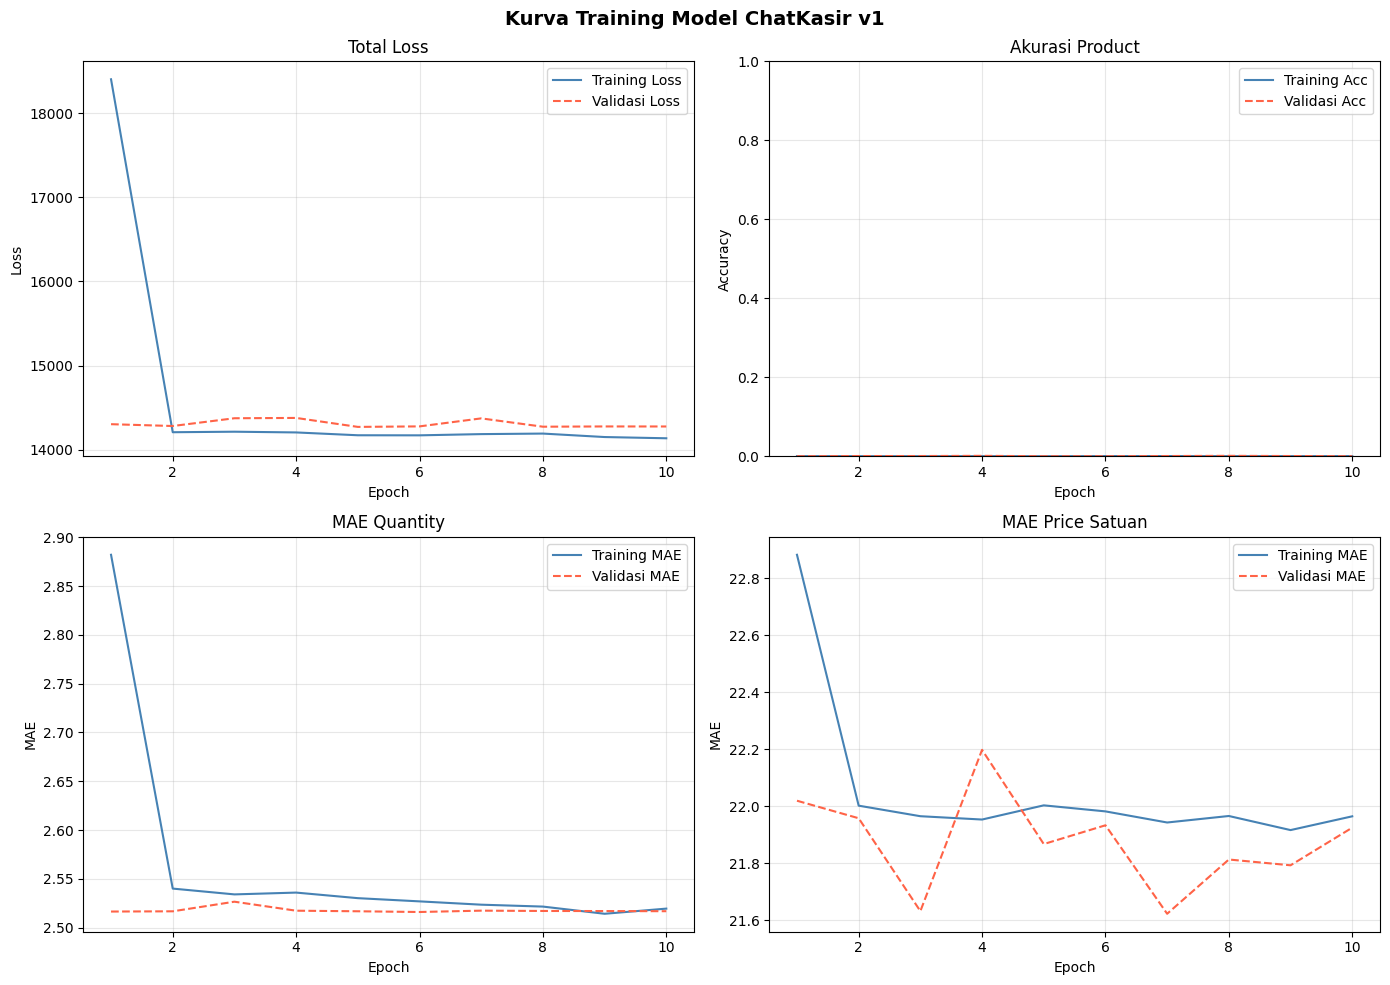

Grafik disimpan ke Google Drive


In [108]:
def plot_training_history(history):
    hist = history.history
    epochs_ran = range(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Kurva Training Model ChatKasir v1", fontsize=14, fontweight="bold")

    # plot 1: Total Loss (training dan validasi)
    axes[0, 0].plot(epochs_ran, hist["loss"], label="Training Loss", color="steelblue")
    axes[0, 0].plot(epochs_ran, hist["val_loss"], label="Validasi Loss", color="tomato", linestyle="--")
    axes[0, 0].set_title("Total Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # plot 2: Akurasi Product
    if "product_accuracy" in hist:
        axes[0, 1].plot(epochs_ran, hist["product_accuracy"], label="Training Acc", color="steelblue")
        axes[0, 1].plot(epochs_ran, hist["val_product_accuracy"], label="Validasi Acc", color="tomato", linestyle="--")
        axes[0, 1].set_title("Akurasi Product")
        axes[0, 1].set_xlabel("Epoch")
        axes[0, 1].set_ylabel("Accuracy")
        axes[0, 1].set_ylim(0, 1)
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.3)

    # plot 3: MAE Quantity
    if "quantity_mae" in hist:
        axes[1, 0].plot(epochs_ran, hist["quantity_mae"], label="Training MAE", color="steelblue")
        axes[1, 0].plot(epochs_ran, hist["val_quantity_mae"], label="Validasi MAE", color="tomato", linestyle="--")
        axes[1, 0].set_title("MAE Quantity")
        axes[1, 0].set_xlabel("Epoch")
        axes[1, 0].set_ylabel("MAE")
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)

    # plot 4: MAE Price Satuan
    if "price_satuan_mae" in hist:
        axes[1, 1].plot(epochs_ran, hist["price_satuan_mae"], label="Training MAE", color="steelblue")
        axes[1, 1].plot(epochs_ran, hist["val_price_satuan_mae"], label="Validasi MAE", color="tomato", linestyle="--")
        axes[1, 1].set_title("MAE Price Satuan")
        axes[1, 1].set_xlabel("Epoch")
        axes[1, 1].set_ylabel("MAE")
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(MODELS_DIR, "training_curves_v1.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

    print("Grafik disimpan ke Google Drive")

plot_training_history(history)

### 6.9 Ringkasan Hasil Training

In [109]:
hist = history.history
epoch_terbaik = int(np.argmin(hist["val_loss"])) + 1

print(f"Ringkasan Training Model v1")
print(f"Epoch terbaik        : {epoch_terbaik} dari {len(hist['loss'])} yang dijalankan")

print(f"\nMetrik di epoch terbaik:")
print(f"Total val_loss       : {min(hist['val_loss']):.4f}")

if "val_product_accuracy" in hist:
    best_acc = hist["val_product_accuracy"][epoch_terbaik - 1]
    print(f"Product val_accuracy : {best_acc:.4f} ({best_acc*100:.1f}%)")

    if best_acc >= 0.85:
        print(f"Target akurasi ≥85% tercapai")
    else:
        print(f"Target ≥85% belum tercapai, perlu iterasi di Minggu 3")

if "val_quantity_mae" in hist:
    best_qty_mae = hist["val_quantity_mae"][epoch_terbaik - 1]
    print(f"Quantity val_MAE     : {best_qty_mae:.4f} porsi")

if "val_price_satuan_mae" in hist:
    best_price_mae = hist["val_price_satuan_mae"][epoch_terbaik - 1]
    print(f"Price val_MAE        : {best_price_mae:.4f} (= Rp{best_price_mae*1000:,.0f})")

print(f"\nModel terbaik sudah disimpan ke Google Drive")
print(f"File: chatkasir_v1_best.keras")

Ringkasan Training Model v1
Epoch terbaik        : 5 dari 10 yang dijalankan

Metrik di epoch terbaik:
Total val_loss       : 14273.1494
Product val_accuracy : 0.0000 (0.0%)
Target ≥85% belum tercapai, perlu iterasi di Minggu 3
Quantity val_MAE     : 2.5168 porsi
Price val_MAE        : 21.8675 (= Rp21,868)

Model terbaik sudah disimpan ke Google Drive
File: chatkasir_v1_best.keras
